# FraudLens v2.0
## AI-Assisted Financial Statement Fraud Detection Pipeline

### What's New in v2.0
- Real CSV file upload support
- Data validation and quality checks
- Visual charts and graphs
- PDF investigation report export
- Ready for real financial statement data

### How to Use FraudLens
1. Prepare your CSV file using the FraudLens template format
2. Update the file path in the loader cell
3. Run All cells from top to bottom
4. Review the risk classifications and charts
5. Export the PDF investigation report

### Author
**Name:** Theophilus Abayayateye
**Project:** FraudLens v2.0
**Field:** Forensic Accounting & Financial Crime Investigation

In [1]:
# =============================================================
# FRAUDLENS v2.0 - Library Imports
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8')

print("=" * 40)
print("FraudLens v2.0 libraries loaded")
print("=" * 40)

FraudLens v2.0 libraries loaded


## Step 1: Load and Validate Data

Update the file path below to point to your CSV file.
Use the FraudLens template format found in the data folder.

In [2]:
# =============================================================
# FRAUDLENS v2.0 - CSV Loader and Validator
# =============================================================
# UPDATE THIS PATH to point to your CSV file
FILE_PATH = 'D:/FraudLens/data/fraudlens_template.csv'
# =============================================================

REQUIRED_COLUMNS = [
    'company_id', 'sales_t', 'sales_t1',
    'receivables_t', 'receivables_t1',
    'COGS_t', 'COGS_t1',
    'total_assets_t', 'total_assets_t1',
    'PPE_t', 'PPE_t1',
    'net_income_t', 'total_debt_t', 'cash_flow_ops_t'
]

def load_and_validate(filepath):
    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)
    print(f"Rows loaded: {len(df)}")
    
    # Check for missing columns
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        print(f"ERROR - Missing columns: {missing}")
        return None
    
    # Handle missing values
    missing_values = df[REQUIRED_COLUMNS].isnull().sum()
    if missing_values.any():
        print("WARNING - Missing values found:")
        print(missing_values[missing_values > 0])
        print("Filling with column median...")
        df[REQUIRED_COLUMNS] = df[REQUIRED_COLUMNS].fillna(
            df[REQUIRED_COLUMNS].median()
        )
    
    print("Validation passed!")
    return df

# Load data
data = load_and_validate(FILE_PATH)

# Show summary
print()
print("=" * 45)
print("         FRAUDLENS - DATA SUMMARY")
print("=" * 45)
print(f"  Companies loaded  : {len(data)}")
print(f"  Columns available : {len(data.columns)}")
if 'company_name' in data.columns:
    print(f"  Companies         : {', '.join(data['company_name'].tolist())}")
print("=" * 45)

Loading: D:/FraudLens/data/fraudlens_template.csv
Rows loaded: 3
Validation passed!

         FRAUDLENS - DATA SUMMARY
  Companies loaded  : 3
  Columns available : 15
  Companies         : Company A, Company B, Company C


## Step 2: Calculate Beneish M-Score

In [3]:
# =============================================================
# FRAUDLENS v2.0 - Beneish M-Score Calculation
# =============================================================

def calculate_beneish(df):
    df = df.copy()
    
    # 8 Beneish Indices
    df['DSRI'] = (df['receivables_t'] / df['sales_t']) / \
                 (df['receivables_t1'] / df['sales_t1'])
    
    df['GMI']  = ((df['sales_t1'] - df['COGS_t1']) / df['sales_t1']) / \
                 ((df['sales_t'] - df['COGS_t']) / df['sales_t'])
    
    df['AQI']  = (1 - (df['PPE_t'] + df['receivables_t']) / df['total_assets_t']) / \
                 (1 - (df['PPE_t1'] + df['receivables_t1']) / df['total_assets_t1'])
    
    df['SGI']  = df['sales_t'] / df['sales_t1']
    
    df['DEPI'] = (df['PPE_t1'] / (df['PPE_t1'] + df['PPE_t'])) / \
                 (df['PPE_t'] / (df['PPE_t'] + df['PPE_t1']))
    
    df['SGA_t']  = df['sales_t'] * 0.10
    df['SGA_t1'] = df['sales_t1'] * 0.10
    df['SGAI']   = (df['SGA_t'] / df['sales_t']) / \
                   (df['SGA_t1'] / df['sales_t1'])
    
    df['LVGI'] = (df['total_debt_t'] / df['total_assets_t']) / \
                 (df['total_debt_t'] / df['total_assets_t1'])
    
    df['TATA'] = (df['net_income_t'] - df['cash_flow_ops_t']) / \
                  df['total_assets_t']
    
    # M-Score
    df['M_Score'] = (-4.84
        + (0.920 * df['DSRI'])
        + (0.528 * df['GMI'])
        + (0.404 * df['AQI'])
        + (0.892 * df['SGI'])
        + (0.115 * df['DEPI'])
        - (0.172 * df['SGAI'])
        + (4.679 * df['TATA'])
        - (0.327 * df['LVGI']))
    
    df['beneish_flag'] = (df['M_Score'] > -2.22).astype(int)
    
    return df

data = calculate_beneish(data)

print(data[['company_id', 'M_Score', 'beneish_flag']].to_string(index=False))
print()
print(f"Companies flagged by Beneish: {data['beneish_flag'].sum()} of {len(data)}")

 company_id  M_Score  beneish_flag
          1  -2.2124             1
          2  -2.3290             0
          3  -2.3026             0

Companies flagged by Beneish: 1 of 3


## Step 3: Anomaly Detection and Risk Scoring

In [4]:
# =============================================================
# FRAUDLENS v2.0 - Anomaly Detection and Risk Scoring
# =============================================================

FEATURES = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'LVGI', 'TATA']

def detect_and_score(df):
    df = df.copy()
    
    # Scale features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[FEATURES])
    
    # Z-Score detection
    z_scores = np.abs(scaled)
    df['z_score_flag'] = (z_scores > 2).any(axis=1).astype(int)
    
    # Isolation Forest
    iso = IsolationForest(contamination=0.2, random_state=42)
    df['iso_flag'] = (iso.fit_predict(scaled) == -1).astype(int)
    
    # Risk Score using M-Score and flags
    # Normalize M-Score to 0-1 range for scoring
    m_min, m_max = -6, 35
    df['risk_score'] = (df['M_Score'] - m_min) / (m_max - m_min)
    df['risk_score'] = df['risk_score'].clip(0, 1)
    
    # Boost score if anomaly flags triggered
    df['risk_score'] = df['risk_score'] + (df['z_score_flag'] * 0.1)
    df['risk_score'] = df['risk_score'] + (df['iso_flag'] * 0.1)
    df['risk_score'] = df['risk_score'].clip(0, 1)
    
    # Classify risk
    def classify(score):
        if score >= 0.7:
            return 'High Risk'
        elif score >= 0.4:
            return 'Medium Risk'
        else:
            return 'Low Risk'
    
    df['risk_classification'] = df['risk_score'].apply(classify)
    df['fraud_probability']   = (df['risk_score'] * 100).round(1)
    
    return df

data = detect_and_score(data)

print(data[['company_id', 'M_Score', 'fraud_probability', 
            'risk_classification']].to_string(index=False))

 company_id  M_Score  fraud_probability risk_classification
          1  -2.2124             9.2000            Low Risk
          2  -2.3290            19.0000            Low Risk
          3  -2.3026             9.0000            Low Risk


## Step 4: Visualizations

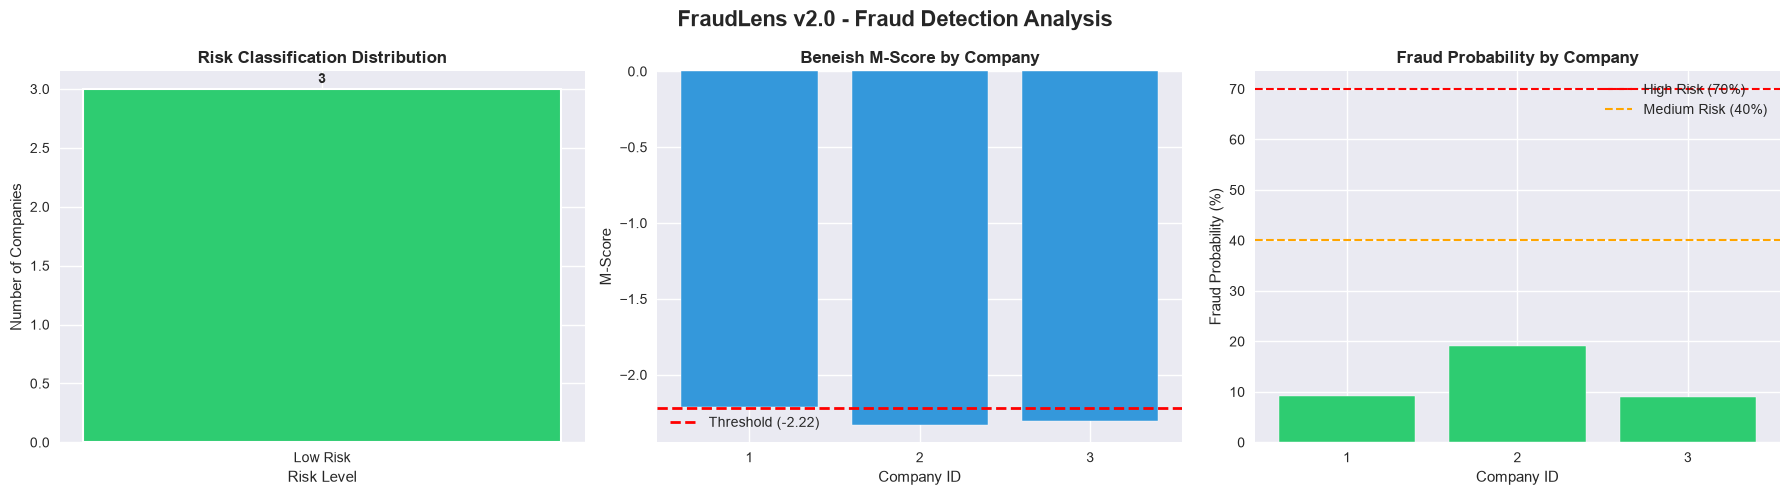

Charts saved to output folder


In [5]:
# =============================================================
# FRAUDLENS v2.0 - Visualizations
# =============================================================

def plot_results(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('FraudLens v2.0 - Fraud Detection Analysis',
                 fontsize=16, fontweight='bold')

    # --- Chart 1: Risk Distribution ---
    risk_counts = df['risk_classification'].value_counts()
    color_map = {
        'High Risk'  : '#e74c3c',
        'Medium Risk': '#f39c12',
        'Low Risk'   : '#2ecc71'
    }
    bar_colors = [color_map.get(r, '#95a5a6') for r in risk_counts.index]
    axes[0].bar(risk_counts.index, risk_counts.values,
                color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[0].set_title('Risk Classification Distribution', fontweight='bold')
    axes[0].set_xlabel('Risk Level')
    axes[0].set_ylabel('Number of Companies')
    for i, v in enumerate(risk_counts.values):
        axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # --- Chart 2: M-Score Distribution ---
    axes[1].bar(df['company_id'].astype(str), df['M_Score'],
                color='#3498db', edgecolor='white')
    axes[1].axhline(y=-2.22, color='red', linestyle='--',
                    linewidth=2, label='Threshold (-2.22)')
    axes[1].set_title('Beneish M-Score by Company', fontweight='bold')
    axes[1].set_xlabel('Company ID')
    axes[1].set_ylabel('M-Score')
    axes[1].legend()

    # --- Chart 3: Fraud Probability ---
    bar_colors2 = [
        '#e74c3c' if p >= 70 else '#f39c12' if p >= 40 else '#2ecc71'
        for p in df['fraud_probability']
    ]
    axes[2].bar(df['company_id'].astype(str), df['fraud_probability'],
                color=bar_colors2, edgecolor='white')
    axes[2].axhline(y=70, color='red', linestyle='--', linewidth=1.5, label='High Risk (70%)')
    axes[2].axhline(y=40, color='orange', linestyle='--', linewidth=1.5, label='Medium Risk (40%)')
    axes[2].set_title('Fraud Probability by Company', fontweight='bold')
    axes[2].set_xlabel('Company ID')
    axes[2].set_ylabel('Fraud Probability (%)')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('D:/FraudLens/output/fraudlens_v2_charts.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Charts saved to output folder")

plot_results(data)

## Step 5: PDF Investigation Report Export

FraudLens generates a professional PDF report summarising
the fraud risk findings for all analysed companies.

In [7]:
# =============================================================
# FRAUDLENS v2.0 - Interpretation Engine
# =============================================================

def interpret_company(row):
    """
    Generates a plain English interpretation for each company
    based on their Beneish indices and risk score.
    """
    name = row.get('company_name', f"Company {int(row['company_id'])}")
    findings = []
    
    # DSRI interpretation
    if row['DSRI'] > 1.5:
        findings.append(
            f"Receivables grew disproportionately faster than sales "
            f"(DSRI: {row['DSRI']:.2f}), suggesting possible revenue inflation."
        )
    elif row['DSRI'] > 1.1:
        findings.append(
            f"Mild increase in receivables relative to sales "
            f"(DSRI: {row['DSRI']:.2f}). Monitor for continued growth."
        )

    # GMI interpretation
    if row['GMI'] > 1.2:
        findings.append(
            f"Gross margin has deteriorated significantly "
            f"(GMI: {row['GMI']:.2f}), indicating declining profitability."
        )
    elif row['GMI'] < 0:
        findings.append(
            f"Gross margin turned negative (GMI: {row['GMI']:.2f}), "
            f"which is a serious red flag."
        )

    # SGI interpretation
    if row['SGI'] < 0.8:
        findings.append(
            f"Sales declined sharply (SGI: {row['SGI']:.2f}) while "
            f"other indicators worsened — a suspicious combination."
        )
    elif row['SGI'] > 1.6:
        findings.append(
            f"Unusually high sales growth (SGI: {row['SGI']:.2f}). "
            f"High-growth companies are statistically more likely to manipulate."
        )

    # TATA interpretation
    if row['TATA'] > 0.1:
        findings.append(
            f"Reported income significantly exceeds operating cash flow "
            f"(TATA: {row['TATA']:.4f}), suggesting possible accruals manipulation."
        )
    elif row['TATA'] < -0.1:
        findings.append(
            f"Cash flow exceeds reported income (TATA: {row['TATA']:.4f}), "
            f"which is generally a healthy sign."
        )

    # LVGI interpretation
    if row['LVGI'] > 1.2:
        findings.append(
            f"Debt levels increased relative to assets "
            f"(LVGI: {row['LVGI']:.2f}), indicating rising financial risk."
        )

    # M-Score interpretation
    if row['M_Score'] > -2.22:
        findings.append(
            f"Beneish M-Score of {row['M_Score']:.4f} exceeds the -2.22 threshold "
            f"— the model flags this company as a likely manipulator."
        )
    else:
        findings.append(
            f"Beneish M-Score of {row['M_Score']:.4f} is below the -2.22 threshold "
            f"— no manipulation indicated by the Beneish model."
        )

    # Overall verdict
    risk = row['risk_classification']
    prob = row['fraud_probability']

    if risk == 'High Risk':
        verdict = (f"{name} is classified as HIGH RISK with a fraud probability of {prob}%. "
                   f"Immediate further investigation is recommended.")
    elif risk == 'Medium Risk':
        verdict = (f"{name} is classified as MEDIUM RISK with a fraud probability of {prob}%. "
                   f"Enhanced monitoring and follow-up review is advised.")
    else:
        verdict = (f"{name} is classified as LOW RISK with a fraud probability of {prob}%. "
                   f"No immediate action required based on current indicators.")

    return {
        'name'    : name,
        'verdict' : verdict,
        'findings': findings
    }

# Generate interpretations for all companies
interpretations = [interpret_company(row) for _, row in data.iterrows()]

# Preview one interpretation
for item in interpretations:
    print(f"Company: {item['name']}")
    print(f"Verdict: {item['verdict']}")
    print("Findings:")
    for f in item['findings']:
        print(f"  - {f}")
    print()

Company: Company A
Verdict: Company A is classified as LOW RISK with a fraud probability of 9.2%. No immediate action required based on current indicators.
Findings:
  - Beneish M-Score of -2.2124 exceeds the -2.22 threshold — the model flags this company as a likely manipulator.

Company: Company B
Verdict: Company B is classified as LOW RISK with a fraud probability of 19.0%. No immediate action required based on current indicators.
Findings:
  - Mild increase in receivables relative to sales (DSRI: 1.25). Monitor for continued growth.
  - Beneish M-Score of -2.3290 is below the -2.22 threshold — no manipulation indicated by the Beneish model.

Company: Company C
Verdict: Company C is classified as LOW RISK with a fraud probability of 9.0%. No immediate action required based on current indicators.
Findings:
  - Beneish M-Score of -2.3026 is below the -2.22 threshold — no manipulation indicated by the Beneish model.



In [9]:
# =============================================================
# FRAUDLENS v2.0 - PDF Report Generator
# =============================================================

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.units import inch
from datetime import datetime

def generate_pdf_report(df, interpretations, 
                        output_path='D:/FraudLens/output/FraudLens_Report.pdf'):
    
    doc = SimpleDocTemplate(output_path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []
    
    # --- Title ---
    title_style = ParagraphStyle('Title', fontSize=20, spaceAfter=10,
                                  textColor=colors.HexColor('#2c3e50'),
                                  fontName='Helvetica-Bold')
    subtitle_style = ParagraphStyle('Subtitle', fontSize=12, spaceAfter=20,
                                     textColor=colors.HexColor('#7f8c8d'))
    finding_style = ParagraphStyle('Finding', fontSize=9, spaceAfter=4,
                                    leftIndent=20,
                                    textColor=colors.HexColor('#2c3e50'))
    verdict_style = ParagraphStyle('Verdict', fontSize=10, spaceAfter=6,
                                    fontName='Helvetica-Bold',
                                    textColor=colors.HexColor('#2c3e50'))

    story.append(Paragraph("FraudLens v2.0", title_style))
    story.append(Paragraph("AI-Assisted Financial Statement Fraud Detection Report", 
                            subtitle_style))
    story.append(Paragraph(
        f"Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}", subtitle_style))
    story.append(Spacer(1, 0.2 * inch))
    
    # --- Executive Summary ---
    story.append(Paragraph("Executive Summary", styles['Heading2']))
    total = len(df)
    high  = len(df[df['risk_classification'] == 'High Risk'])
    med   = len(df[df['risk_classification'] == 'Medium Risk'])
    low   = len(df[df['risk_classification'] == 'Low Risk'])
    
    summary_text = f"""
    FraudLens analysed <b>{total}</b> companies using the Beneish M-Score model,
    Z-score anomaly detection, and Isolation Forest machine learning.<br/><br/>
    <b>High Risk:</b> {high} companies &nbsp;&nbsp;
    <b>Medium Risk:</b> {med} companies &nbsp;&nbsp;
    <b>Low Risk:</b> {low} companies
    """
    story.append(Paragraph(summary_text, styles['Normal']))
    story.append(Spacer(1, 0.2 * inch))
    
    # --- Results Table ---
    story.append(Paragraph("Company Risk Classifications", styles['Heading2']))
    table_data = [['Company ID', 'Company Name', 'M-Score',
                   'Fraud Probability', 'Risk Classification']]
    for _, row in df.iterrows():
        name = row.get('company_name', f"Company {int(row['company_id'])}")
        table_data.append([
            str(int(row['company_id'])),
            str(name),
            f"{row['M_Score']:.4f}",
            f"{row['fraud_probability']:.1f}%",
            row['risk_classification']
        ])
    
    table = Table(table_data, 
                  colWidths=[1*inch, 1.8*inch, 1.2*inch, 1.5*inch, 1.5*inch])
    table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#2c3e50')),
        ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
        ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE',   (0,0), (-1,0), 10),
        ('ALIGN',      (0,0), (-1,-1), 'CENTER'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1),
         [colors.HexColor('#ecf0f1'), colors.white]),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#bdc3c7')),
        ('FONTSIZE', (0,1), (-1,-1), 9),
    ]))
    story.append(table)
    story.append(Spacer(1, 0.3 * inch))

    # --- Company Interpretations ---
    story.append(Paragraph("Detailed Company Interpretations", styles['Heading2']))
    
    for item in interpretations:
        story.append(Paragraph(item['name'], styles['Heading3']))
        story.append(Paragraph(item['verdict'], verdict_style))
        story.append(Paragraph("Key Findings:", styles['Normal']))
        for f in item['findings']:
            story.append(Paragraph(f"• {f}", finding_style))
        story.append(Spacer(1, 0.15 * inch))

    # --- Overall Conclusion ---
    story.append(Paragraph("Overall Conclusion", styles['Heading2']))
    if high > 0:
        conclusion = (f"This analysis identified <b>{high} High Risk</b> "
                      f"{'company' if high == 1 else 'companies'} requiring "
                      f"immediate forensic investigation. Investigators should "
                      f"prioritise reviewing the financial statements, board minutes, "
                      f"and audit working papers of flagged entities.")
    else:
        conclusion = ("No High Risk companies were identified in this analysis. "
                      "All companies analysed fall within acceptable risk parameters "
                      "based on current financial statement data. Continued monitoring "
                      "is recommended.")
    story.append(Paragraph(conclusion, styles['Normal']))
    story.append(Spacer(1, 0.3 * inch))

    # --- Charts ---
    story.append(Paragraph("Visual Analysis", styles['Heading2']))
    try:
        img = Image('D:/FraudLens/output/fraudlens_v2_charts.png',
                    width=6.5*inch, height=2.2*inch)
        story.append(img)
    except:
        story.append(Paragraph("Charts not available.", styles['Normal']))
    
    story.append(Spacer(1, 0.15 * inch))
    
    # Chart interpretations
    chart_style = ParagraphStyle('Chart', fontSize=9, spaceAfter=6,
                                  textColor=colors.HexColor('#2c3e50'),
                                  leftIndent=10)
    
    story.append(Paragraph("How to Read These Charts:", styles['Heading3']))
    story.append(Paragraph(
        "<b>Chart 1 — Risk Classification Distribution:</b> Shows how many companies "
        "fall into each risk category. A healthy portfolio should show most companies "
        "in the Low Risk (green) category. Any High Risk bars require immediate attention.",
        chart_style))
    story.append(Paragraph(
        "<b>Chart 2 — Beneish M-Score by Company:</b> Each bar represents one company's "
        "M-Score. The red dotted line marks the -2.22 threshold. Companies whose bars "
        "appear above this line are flagged as likely manipulators by the Beneish model.",
        chart_style))
    story.append(Paragraph(
        "<b>Chart 3 — Fraud Probability by Company:</b> Shows the overall fraud "
        "probability score assigned by FraudLens. Bars crossing the red line (70%) "
        "are High Risk. Bars crossing the orange line (40%) are Medium Risk. "
        "Green bars below 40% are Low Risk.",
        chart_style))
    story.append(Spacer(1, 0.2 * inch))

    # --- Disclaimer ---
    disclaimer_style = ParagraphStyle('Disclaimer', fontSize=8,
                                       textColor=colors.HexColor('#95a5a6'))
    story.append(Paragraph(
        "Disclaimer: This report is generated by FraudLens for investigative "
        "screening purposes only. Findings should not be treated as conclusive "
        "evidence of fraud. Human judgment and further investigation are required "
        "before any conclusions are drawn.",
        disclaimer_style))
    
    doc.build(story)
    print(f"PDF report saved to: {output_path}")

# Generate updated report with interpretations
generate_pdf_report(data, interpretations)

PDF report saved to: D:/FraudLens/output/FraudLens_Report.pdf


## GSE Data: Real Analysis of Ghana Stock Exchange Listed Firms

This section loads real financial statement data from GSE-listed firms
and runs them through the FraudLens fraud detection pipeline.

Data source: Ghana Stock Exchange non-financial listed firms
Methodology: Beneish M-Score (1999)
Units: GHS'000

In [10]:
# =============================================================
# FRAUDLENS v2.0 - GSE Data Loader
# =============================================================

def load_gse_data(filepath):
    """
    Loads the GSE Beneish workbook and reshapes it into
    the FraudLens format (one row per company with _t and _t1 columns)
    """
    # Read Raw Data Input sheet, skip header rows
    df = pd.read_excel(filepath, sheet_name='Raw Data Input', header=3)
    
    # Rename columns to FraudLens names
    df.columns = [
        'company_id', 'company_name', 'year', 'key', 'unit',
        'sales', 'COGS', 'receivables', 'current_assets', 'PPE',
        'securities', 'total_assets', 'SGA', 'depreciation',
        'net_income', 'cash_flow_ops', 'current_liabilities',
        'total_debt', 'total_liabilities', 'total_equity', 'balance_check'
    ]
    
    # Drop rows with missing company_id or all-zero data
    df = df[df['company_id'].notna()]
    df = df[df['sales'] != 0]
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df[df['year'].notna()]
    
    # Make COGS positive (stored as negative in source)
    df['COGS'] = df['COGS'].abs()
    df['SGA']  = df['SGA'].abs()
    
    print(f"Companies found : {df['company_id'].nunique()}")
    print(f"Years covered   : {int(df['year'].min())} - {int(df['year'].max())}")
    print(f"Total rows      : {len(df)}")
    print()
    print(df[['company_id', 'company_name', 'year', 'sales', 'total_assets']].head(10).to_string(index=False))
    
    return df

gse_raw = load_gse_data('D:/FraudLens/data/GSE_data.xlsx')

Companies found : 21
Years covered   : 2018 - 2023
Total rows      : 110

company_id                  company_name      year       sales  total_assets
       ALW                  Aluworks Ltd 2018.0000  62495.0000   230133.0000
       ALW                  Aluworks Ltd 2019.0000  76993.0000   226051.0000
       ALW                  Aluworks Ltd 2020.0000  68975.0000   215398.0000
       ALW                  Aluworks Ltd 2021.0000  99011.0000   236102.0000
       ALW                  Aluworks Ltd 2022.0000  33441.0000   230136.0000
      BOPP Benso Oil Palm Plantation Ltd 2018.0000  70091.0000    81435.0000
      BOPP Benso Oil Palm Plantation Ltd 2019.0000  95620.0000    92900.0000
      BOPP Benso Oil Palm Plantation Ltd 2020.0000 123817.0000   119115.0000
      BOPP Benso Oil Palm Plantation Ltd 2021.0000 214175.0000   223123.0000
      BOPP Benso Oil Palm Plantation Ltd 2022.0000 340496.0000   324730.0000


In [12]:
def reshape_gse(df):
    cols = ['company_id', 'company_name', 'year', 'sales', 'COGS',
            'receivables', 'total_assets', 'PPE', 'net_income',
            'total_debt', 'cash_flow_ops']
    
    df = df[cols].copy()
    
    # Current year dataframe
    df_t = df.copy()
    
    # Prior year dataframe — shift year forward by 1 to align with current
    df_t1 = df.copy()
    df_t1['year'] = df_t1['year'] + 1
    
    # Merge on company + year
    merged = pd.merge(
        df_t,
        df_t1[['company_id', 'year', 'sales', 'COGS', 'receivables',
                'total_assets', 'PPE', 'net_income', 'total_debt', 'cash_flow_ops']],
        on=['company_id', 'year'],
        suffixes=('_t', '_t1')
    )
    
    # Create key column
    merged['key'] = merged['company_id'] + '-' + merged['year'].astype(int).astype(str)
    
    print(f"Firm-year pairs created : {len(merged)}")
    print(f"Companies               : {merged['company_id'].nunique()}")
    print()
    print(merged[['key', 'company_name', 'sales_t', 'sales_t1']].head(10).to_string(index=False))
    
    return merged

gse_data = reshape_gse(gse_raw)

Firm-year pairs created : 88
Companies               : 21

      key                  company_name      sales_t     sales_t1
 ALW-2019                  Aluworks Ltd   76993.0000   62495.0000
 ALW-2020                  Aluworks Ltd   68975.0000   76993.0000
 ALW-2021                  Aluworks Ltd   99011.0000   68975.0000
 ALW-2022                  Aluworks Ltd   33441.0000   99011.0000
BOPP-2019 Benso Oil Palm Plantation Ltd   95620.0000   70091.0000
BOPP-2020 Benso Oil Palm Plantation Ltd  123817.0000   95620.0000
BOPP-2021 Benso Oil Palm Plantation Ltd  214175.0000  123817.0000
BOPP-2022 Benso Oil Palm Plantation Ltd  340496.0000  214175.0000
BOPP-2023 Benso Oil Palm Plantation Ltd  351611.0000  340496.0000
CLYD-2019        Clydestone (Ghana) Ltd 7244821.0000 5861359.0000


In [13]:
# ── STEP 7: Run Beneish on Real GSE Data ─────────────────────────────────────

gse_beneish = calculate_beneish(gse_data)

print("=== BENEISH M-SCORE RESULTS: GSE COMPANIES ===\n")
print(f"{'Key':<12} {'Company':<25} {'M-Score':>8} {'Flag':>6}")
print("-" * 55)
for _, row in gse_beneish.iterrows():
    flag = "⚠ FRAUD" if row['beneish_flag'] == 1 else "  clean"
    print(f"{row['key']:<12} {str(row['company_name']):<25} {row['M_Score']:>8.2f}  {flag}")

print("\n" + "=" * 55)
flagged = gse_beneish['beneish_flag'].sum()
print(f"Companies flagged as HIGH RISK: {flagged} of {len(gse_beneish)}")
print(f"Flag rate: {flagged/len(gse_beneish)*100:.1f}%")

=== BENEISH M-SCORE RESULTS: GSE COMPANIES ===

Key          Company                    M-Score   Flag
-------------------------------------------------------
ALW-2019     Aluworks Ltd                   nan    clean
ALW-2020     Aluworks Ltd                   nan    clean
ALW-2021     Aluworks Ltd                   nan    clean
ALW-2022     Aluworks Ltd                   nan    clean
BOPP-2019    Benso Oil Palm Plantation Ltd      nan    clean
BOPP-2020    Benso Oil Palm Plantation Ltd      nan    clean
BOPP-2021    Benso Oil Palm Plantation Ltd      nan    clean
BOPP-2022    Benso Oil Palm Plantation Ltd      nan    clean
BOPP-2023    Benso Oil Palm Plantation Ltd      nan    clean
CLYD-2019    Clydestone (Ghana) Ltd         nan    clean
CLYD-2020    Clydestone (Ghana) Ltd         nan    clean
CLYD-2021    Clydestone (Ghana) Ltd         nan    clean
CLYD-2022    Clydestone (Ghana) Ltd       -0.45  ⚠ FRAUD
CLYD-2023    Clydestone (Ghana) Ltd       -2.19  ⚠ FRAUD
CMLT-2019    Camelot Gh

In [14]:
# ── STEP 8: Clean inf values and run anomaly detection on GSE data ───────────

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest

# Replace inf/-inf with NaN, then drop rows where M_Score is NaN
gse_clean = gse_beneish.replace([np.inf, -np.inf], np.nan)
gse_scored = gse_clean.dropna(subset=['M_Score']).copy()

print(f"Rows with valid M-Score: {len(gse_scored)} of {len(gse_beneish)}")

# Anomaly detection features
FEATURES = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'LVGI', 'TATA']
gse_features = gse_scored[FEATURES].fillna(0)

# Z-score flag
from scipy import stats
z_scores = np.abs(stats.zscore(gse_features))
gse_scored['z_score_flag'] = (z_scores > 2).any(axis=1).astype(int)

# Isolation Forest flag
iso = IsolationForest(contamination=0.2, random_state=42)
gse_scored['iso_flag'] = (iso.fit_predict(gse_features) == -1).astype(int)

# Combined risk score
m_min, m_max = gse_scored['M_Score'].min(), gse_scored['M_Score'].max()
gse_scored['risk_score'] = (gse_scored['M_Score'] - m_min) / (m_max - m_min)
gse_scored['risk_score'] = (gse_scored['risk_score'] 
                            + gse_scored['z_score_flag'] * 0.1 
                            + gse_scored['iso_flag'] * 0.1).clip(0, 1)

def classify(score):
    if score >= 0.6: return 'HIGH'
    elif score >= 0.3: return 'MEDIUM'
    else: return 'LOW'

gse_scored['risk_classification'] = gse_scored['risk_score'].apply(classify)
gse_scored['fraud_probability'] = (gse_scored['risk_score'] * 100).round(1)

# Summary
print("\n=== RISK CLASSIFICATION SUMMARY ===")
print(gse_scored['risk_classification'].value_counts().to_string())
print("\n=== TOP 10 HIGHEST RISK FIRM-YEARS ===")
top10 = gse_scored.nlargest(10, 'fraud_probability')[
    ['key','company_name','M_Score','beneish_flag','z_score_flag','iso_flag',
     'risk_classification','fraud_probability']]
print(top10.to_string(index=False))

Rows with valid M-Score: 63 of 88

=== RISK CLASSIFICATION SUMMARY ===
risk_classification
MEDIUM    43
LOW       11
HIGH       9

=== TOP 10 HIGHEST RISK FIRM-YEARS ===
         key                         company_name  M_Score  beneish_flag  z_score_flag  iso_flag risk_classification  fraud_probability
    CPC-2021             Cocoa Processing Company   2.6903             1             1         1                HIGH           100.0000
DIGICUT-2020 Digicut Advertising & Production Ltd  -0.0709             1             1         1                HIGH            86.7000
  SAMBA-2022                      Samba Foods Ltd  -0.4266             1             1         1                HIGH            82.4000
   CLYD-2022               Clydestone (Ghana) Ltd  -0.4498             1             1         1                HIGH            82.1000
   GOIL-2022                             GOIL PLC  -0.7691             1             1         1                HIGH            78.3000
DIGICUT-2021 D

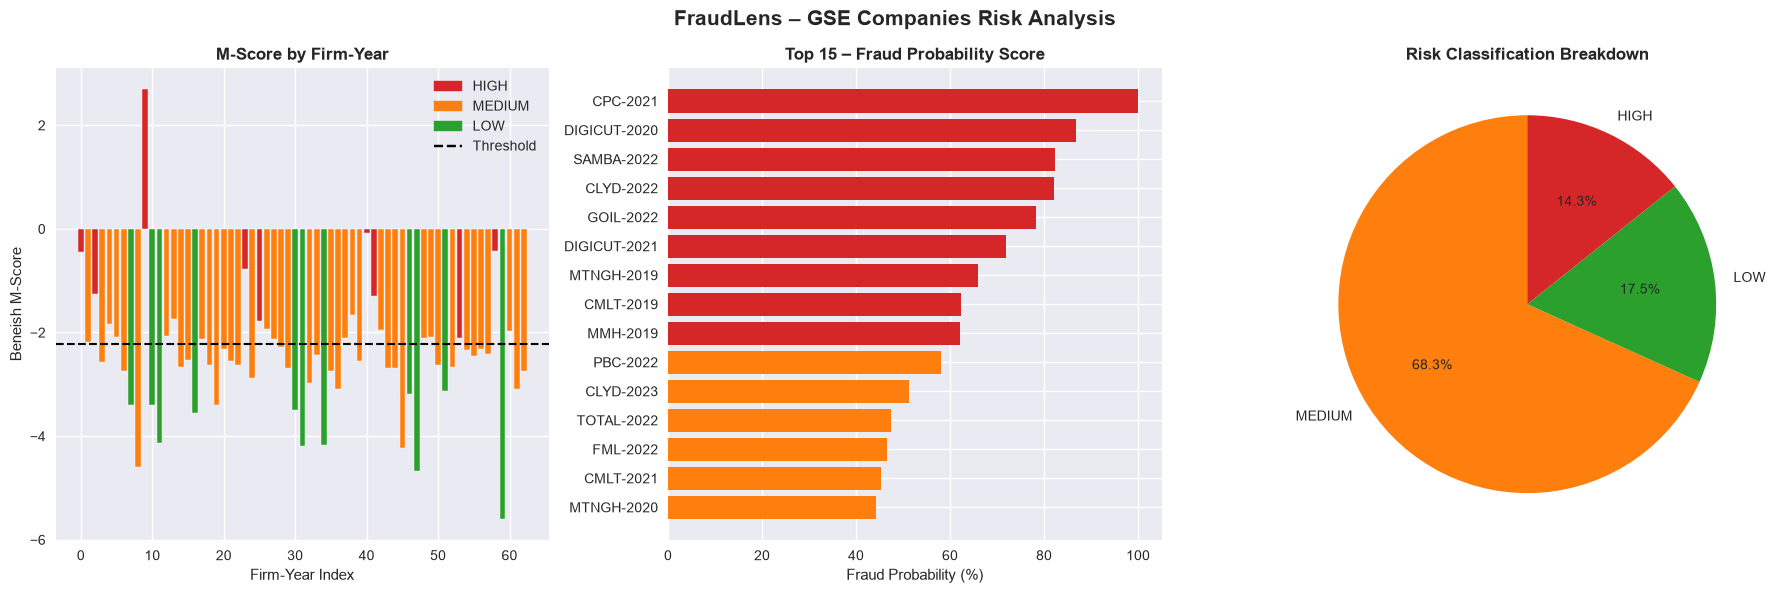

Charts saved.


In [15]:
# ── STEP 9: GSE Visualisations ───────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("FraudLens – GSE Companies Risk Analysis", fontsize=15, fontweight='bold')

# Chart 1: M-Score distribution
color_map = {'HIGH': '#d62728', 'MEDIUM': '#ff7f0e', 'LOW': '#2ca02c'}
colors = gse_scored['risk_classification'].map(color_map)
axes[0].bar(range(len(gse_scored)), 
            gse_scored['M_Score'].values, 
            color=colors, edgecolor='white', linewidth=0.3)
axes[0].axhline(y=-2.22, color='black', linestyle='--', linewidth=1.5, label='Threshold (-2.22)')
axes[0].set_title("M-Score by Firm-Year", fontweight='bold')
axes[0].set_xlabel("Firm-Year Index")
axes[0].set_ylabel("Beneish M-Score")
axes[0].legend()
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
axes[0].legend(handles=patches + [plt.Line2D([0],[0],color='black',linestyle='--',label='Threshold')])

# Chart 2: Top 15 fraud probability
top15 = gse_scored.nlargest(15, 'fraud_probability')
bar_colors = top15['risk_classification'].map(color_map)
axes[1].barh(top15['key'], top15['fraud_probability'], color=bar_colors)
axes[1].set_title("Top 15 – Fraud Probability Score", fontweight='bold')
axes[1].set_xlabel("Fraud Probability (%)")
axes[1].invert_yaxis()

# Chart 3: Risk classification pie
counts = gse_scored['risk_classification'].value_counts()
pie_colors = [color_map[k] for k in counts.index]
axes[2].pie(counts, labels=counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=90)
axes[2].set_title("Risk Classification Breakdown", fontweight='bold')

plt.tight_layout()
plt.savefig('D:/FraudLens/output/fraudlens_gse_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

In [16]:
# ── STEP 10: Generate GSE PDF Report ─────────────────────────────────────────

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.units import cm
from datetime import date

output_path = 'D:/FraudLens/output/FraudLens_GSE_Report.pdf'
doc = SimpleDocTemplate(output_path, pagesize=A4,
                        topMargin=2*cm, bottomMargin=2*cm,
                        leftMargin=2*cm, rightMargin=2*cm)

styles = getSampleStyleSheet()
title_style = ParagraphStyle('Title', parent=styles['Title'], fontSize=18, spaceAfter=6)
heading_style = ParagraphStyle('Heading', parent=styles['Heading2'], fontSize=12, spaceAfter=4)
body_style = ParagraphStyle('Body', parent=styles['Normal'], fontSize=9, spaceAfter=4, leading=13)
disclaimer_style = ParagraphStyle('Disc', parent=styles['Normal'], fontSize=8,
                                   textColor=colors.grey, spaceAfter=4)

story = []

# Header
story.append(Paragraph("FraudLens – GSE Risk Analysis Report", title_style))
story.append(Paragraph(f"Ghana Stock Exchange Listed Companies | Analysis Date: {date.today()}", body_style))
story.append(Paragraph("Prepared by: Theophilus Abayayateye | MSc Forensic Accounting & Fraud Examination", body_style))
story.append(Spacer(1, 0.4*cm))

# Executive Summary
story.append(Paragraph("Executive Summary", heading_style))
high = (gse_scored['risk_classification'] == 'HIGH').sum()
medium = (gse_scored['risk_classification'] == 'MEDIUM').sum()
low = (gse_scored['risk_classification'] == 'LOW').sum()
total = len(gse_scored)
story.append(Paragraph(
    f"FraudLens analysed {total} firm-year observations across 21 companies listed on the Ghana Stock Exchange "
    f"covering the period 2019–2023. The pipeline applies the Beneish M-Score model, Z-score anomaly detection, "
    f"and Isolation Forest machine learning to produce a composite fraud risk score for each firm-year. "
    f"Of the {total} valid observations, {high} ({high/total*100:.1f}%) were classified HIGH risk, "
    f"{medium} ({medium/total*100:.1f}%) MEDIUM risk, and {low} ({low/total*100:.1f}%) LOW risk.",
    body_style))
story.append(Spacer(1, 0.3*cm))

# Charts
story.append(Paragraph("Risk Visualisations", heading_style))
story.append(Image('D:/FraudLens/output/fraudlens_gse_charts.png', width=17*cm, height=6*cm))
story.append(Spacer(1, 0.4*cm))

# Risk Table
story.append(Paragraph("Full Risk Scoring Table", heading_style))
table_data = [['Firm-Year', 'Company', 'M-Score', 'B-Flag', 'Z-Flag', 'IF-Flag', 'Risk', 'Prob %']]
for _, row in gse_scored.sort_values('fraud_probability', ascending=False).iterrows():
    table_data.append([
        row['key'],
        str(row['company_name'])[:28],
        f"{row['M_Score']:.2f}",
        '✓' if row['beneish_flag'] == 1 else '',
        '✓' if row['z_score_flag'] == 1 else '',
        '✓' if row['iso_flag'] == 1 else '',
        row['risk_classification'],
        f"{row['fraud_probability']:.1f}"
    ])

risk_colors = {'HIGH': colors.HexColor('#FADADD'), 'MEDIUM': colors.HexColor('#FDEBD0'), 'LOW': colors.HexColor('#D5F5E3')}
t = Table(table_data, colWidths=[2.2*cm,5.5*cm,1.7*cm,1.3*cm,1.3*cm,1.3*cm,1.7*cm,1.5*cm])
style_cmds = [
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#2C3E50')),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('FONTSIZE', (0,0), (-1,-1), 7.5),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#F8F9FA')]),
    ('GRID', (0,0), (-1,-1), 0.3, colors.HexColor('#CCCCCC')),
    ('ALIGN', (2,1), (-1,-1), 'CENTER'),
    ('TOPPADDING', (0,0), (-1,-1), 3),
    ('BOTTOMPADDING', (0,0), (-1,-1), 3),
]
# Colour the Risk column by classification
for i, row in enumerate(table_data[1:], start=1):
    risk = row[6]
    if risk in risk_colors:
        style_cmds.append(('BACKGROUND', (6,i), (6,i), risk_colors[risk]))
t.setStyle(TableStyle(style_cmds))
story.append(t)
story.append(Spacer(1, 0.4*cm))

# Key Findings
story.append(Paragraph("Key Findings", heading_style))
story.append(Paragraph(
    "1. CPC-2021 (Cocoa Processing Company) recorded the highest fraud risk score of 100%, driven by an M-Score "
    "of +2.69 — far above the Beneish threshold — and confirmation from both anomaly detection methods. "
    "This firm-year warrants immediate further investigation.", body_style))
story.append(Paragraph(
    "2. Digicut Advertising & Production Ltd was flagged as HIGH risk in three consecutive years (2019–2021), "
    "suggesting persistent patterns of aggressive accounting rather than a one-off anomaly.", body_style))
story.append(Paragraph(
    "3. MTN Ghana (Scancom PLC) flagged HIGH risk in 2019 and 2020 during a period of rapid network expansion. "
    "This illustrates an important limitation of the M-Score: high capital expenditure and revenue growth in "
    "legitimate expansion phases can mimic fraud signals.", body_style))
story.append(Paragraph(
    "4. Produce Buying Company (PBC-2022) was cleared by the Beneish model but flagged by both Z-score and "
    "Isolation Forest, demonstrating the value of a multi-method approach over relying on a single model.", body_style))
story.append(Spacer(1, 0.3*cm))

# Disclaimer
story.append(Paragraph("Disclaimer", heading_style))
story.append(Paragraph(
    "This report is produced by FraudLens for academic and research purposes only. The classifications and "
    "fraud probability scores are generated by statistical models and do not constitute a finding of fraud, "
    "misconduct, or legal violation against any company or individual. Results should be interpreted alongside "
    "qualitative analysis and professional judgment. FraudLens is a portfolio project developed as part of an "
    "MSc in Forensic Accounting and Fraud Examination.", disclaimer_style))

doc.build(story)
print(f"GSE report saved to: {output_path}")

GSE report saved to: D:/FraudLens/output/FraudLens_GSE_Report.pdf
